### Don't trust your machine

In extreme cases, different algorithms that implement the same mathematical solution may yield different results. This issue is related to the finite representation of numbers in a computer and the propagation of error when an operation is performed

In [1]:
from math import sqrt, factorial, exp
import matplotlib.pyplot as plt

### Example 1

This equation:

$$
    x ^ 2 - q x + 1 = 0 \qquad q = p + \frac{1}{p}
$$

Has two solutions:

$$
    x_1 = \frac{q + \sqrt{q ^ 2 - 4}}{2}, \quad x_2 = \frac{q - \sqrt{q ^ 2 - 4}}{2}
$$

But we can also compute them using $p$:

$$
    x_1 = p, \quad x_2 = \frac{1}{p}
$$

Let's choose $p = 10 ^ k$ and see what happens when we increase $k$

In [2]:
def solve(k):

    p = 10 ** k
    q = p + (1 / p)

    # Using quadratic formula with q
    x1_q = (q + sqrt(q ** 2 - 4)) / 2 
    x2_q = (q - sqrt(q ** 2 - 4)) / 2
    
    # Using quadratic formula with p
    x1_p = p
    x2_p = 1 / p

    err1 = abs(x1_q - x1_p) / x1_p # x_1 relative error
    err2 = abs(x2_q - x2_p) / x2_p # x_2 relative error

    sol = {
        'x1_q': x1_q,
        'err1': err1,
        'x2_q': x2_q,
        'err2': err2
    }
    
    return sol

In [3]:
solve(2)

{'x1_q': 100.0,
 'err1': 0.0,
 'x2_q': 0.00999999999999801,
 'err2': 1.9897278269453977e-13}

In [4]:
solve(3)

{'x1_q': 1000.0,
 'err1': 0.0,
 'x2_q': 0.0009999999999763531,
 'err2': 2.3646883062777846e-11}

In [5]:
solve(4)

{'x1_q': 10000.0,
 'err1': 0.0,
 'x2_q': 0.00010000000020227162,
 'err2': 2.0227161688212564e-09}

In [6]:
solve(5)

{'x1_q': 100000.0,
 'err1': 0.0,
 'x2_q': 1.0000003385357559e-05,
 'err2': 3.3853575579092333e-07}

In [7]:
solve(6)

{'x1_q': 1000000.0,
 'err1': 0.0,
 'x2_q': 1.00000761449337e-06,
 'err2': 7.614493370101404e-06}

In [8]:
solve(7)

{'x1_q': 10000000.0,
 'err1': 0.0,
 'x2_q': 9.96515154838562e-08,
 'err2': 0.003484845161437943}

In [9]:
solve(8)

{'x1_q': 100000000.0,
 'err1': 0.0,
 'x2_q': 1.4901161193847656e-08,
 'err2': 0.49011611938476557}

In [10]:
solve(9)

{'x1_q': 1000000000.0, 'err1': 0.0, 'x2_q': 0.0, 'err2': 1.0}

As you can see, when $p \rightarrow + \infty$ the quadratic formula using $q$ yields incorrect values of $x_2$ due to rounding error, even though the underlying mathematics is the same!

In [11]:
err2_values = [solve(k)['err2'] for k in range(1,10)]
err2_values

[3.608224830031759e-15,
 1.9897278269453977e-13,
 2.3646883062777846e-11,
 2.0227161688212564e-09,
 3.3853575579092333e-07,
 7.614493370101404e-06,
 0.003484845161437943,
 0.49011611938476557,
 1.0]

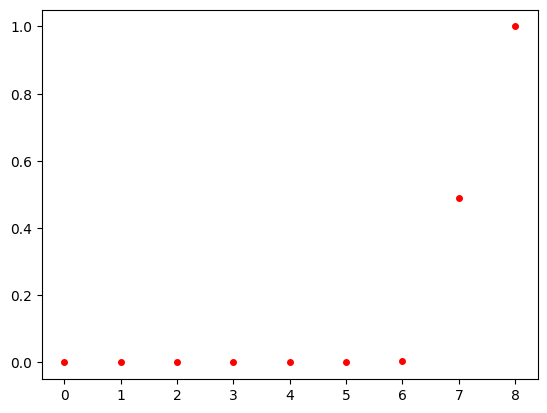

In [12]:
plt.plot(err2_values, 'o', color = 'red', markersize = 4)
plt.show()

---

### Example 2

Compute this limit:

$$
    \lim_{x \rightarrow + \infty} x \, \left( \sqrt{x ^ 2 + 1} - x \right)
$$

We choose three equivalent formulations of this function:

$$
    f_1(x) = x \, \left( \sqrt{x ^ 2 + 1} - x \right)
$$

$$
    f_2(x) = x \, \sqrt{x ^ 2 + 1} - x ^ 2
$$

$$
    f_3(x) = \frac{x}{x + \sqrt{x ^ 2 + 1}}
$$

Let's what happens

In [13]:
def limit(k):
    
    x = 10 ** k
    rad = sqrt(x ** 2 + 1) # Pre-computed radical
    
    f1 = x * (rad - x)
    f2 = x * rad - x ** 2
    f3 = x / (x + rad)
    
    sol = {
        'f1': f1,
        'f2': f2,
        'f3': f3
    }

    return sol

In [14]:
limit(2)

{'f1': 0.4999875006248544, 'f2': 0.49998750062513864, 'f3': 0.4999875006249609}

In [15]:
limit(3)

{'f1': 0.4999998750463419, 'f2': 0.4999998750863597, 'f3': 0.4999998750000625}

In [16]:
limit(4)

{'f1': 0.5000000055588316, 'f2': 0.5, 'f3': 0.49999999874999995}

In [17]:
limit(5)

{'f1': 0.4999994416721165, 'f2': 0.5, 'f3': 0.49999999998750005}

In [18]:
limit(6)

{'f1': 0.500003807246685, 'f2': 0.5, 'f3': 0.499999999999875}

In [19]:
limit(7)

{'f1': 0.5029141902923584, 'f2': 0.5, 'f3': 0.4999999999999987}

In [20]:
limit(8)

{'f1': 0.0, 'f2': 0.0, 'f3': 0.5}

As you can see, when $x \rightarrow + \infty$, the computer yields 0 or 0.5, depending on our choice of $f(x)$, even though they're equivalent mathematically. Let's compute the true limit

In [21]:
import sympy as smp

x = smp.symbols('x', real = True, positive = True)
func = x * (smp.sqrt(x ** 2 + 1) - x)

In [22]:
# First method: Taylor trick
expr = func.subs(x, 1 / x).radsimp()

sol1 = smp.series(expr = expr,
                  x = x,
                  x0 = 0,
                  n = 2,
                  dir = '+').removeO()

In [23]:
# Second method: limit function from SymPy
sol2 = smp.limit(func, x, smp.oo, dir = '+')

In [24]:
sol1, sol2

(1/2, 1/2)

$\frac{1}{2}$ is the right answer

---

### Example 3

Let's compute $e ^ {- 20}$ using three methods:

- Method 1: Taylor expansion at $x = - 20$, truncated at $n = 100$
- Method 2: 'exp()' method from 'math' library
- Method 3: inverse of Taylor expansion at $x = 20$, truncated at $n = 100$

Will they yield the same result?

In [25]:
# Terms of expansion at x = -20
terms = [ ((- 20) ** k) / (factorial(k)) for k in range(100)]
terms

[1.0,
 -20.0,
 200.0,
 -1333.3333333333333,
 6666.666666666667,
 -26666.666666666668,
 88888.88888888889,
 -253968.25396825396,
 634920.6349206349,
 -1410934.7442680777,
 2821869.4885361553,
 -5130671.797338464,
 8551119.662230773,
 -13155568.711124267,
 18793669.58732038,
 -25058226.116427176,
 31322782.645533968,
 -36850332.524157606,
 40944813.91573068,
 -43099804.12182177,
 43099804.12182177,
 -41047432.49697311,
 37315847.72452101,
 -32448563.23871392,
 27040469.365594935,
 -21632375.49247595,
 16640288.840366114,
 -12326139.881752677,
 8804385.62982334,
 -6071990.089533338,
 4047993.3930222257,
 -2611608.6406595004,
 1632255.4004121877,
 -989245.6972195077,
 581909.2336585339,
 -332519.5620905908,
 184733.09005032823,
 -99855.72435152877,
 52555.64439554146,
 -26951.612510534083,
 13475.806255267042,
 -6573.564026959532,
 3130.268584266444,
 -1455.9388764029973,
 661.7903983649987,
 -294.1290659399994,
 127.88220258260844,
 -54.41795854579083,
 22.674149394079514,
 -9.25475485472

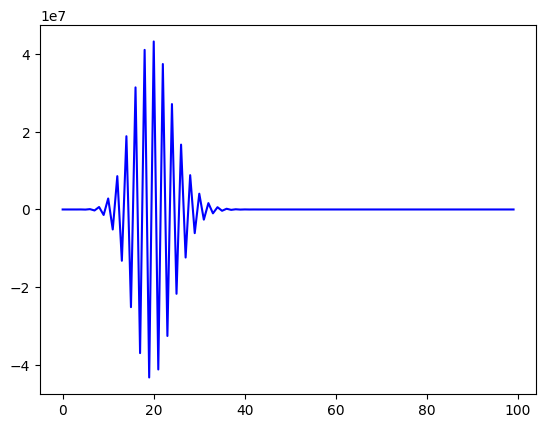

In [26]:
# High oscillations of Taylor expansion's terms ---> catastrophic cancellation!
plt.plot(terms, '-', color = 'blue')
plt.show()

In [27]:
# Computing the sum
value_1 = sum(terms)
value_1

7.167489325072426e-10

In [28]:
# Using exp form math
value_2 = exp(-20)
value_2

2.061153622438558e-09

In [29]:
# Computing 1 / (Taylor series at x = 20)
terms_2 = [ ((20) ** k) / (factorial(k)) for k in range(100)]
value_3 = 1 / sum(terms_2)
value_3

2.061153622438558e-09

In [30]:
# Relative error
(value_2 - value_1) / value_2

0.6522583641003651

1 / (...) is better than computing the Taylor expansion directly at $x = - 20$